In [1]:
# Notebook ekranını genişletmek ve çıktıyı temiz göstermek için:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# Ağ Trafiği Anomali Tespiti — Maliyet Odaklı Siber Güvenlik Modeli

**Ders:** Python ile Veri Bilimi | **Tema:** Cost-Sensitive Analitik (Tema 2)

Bu proje, gerçek Wireshark ağ trafik verisini IANA resmi port/servis veritabanıyla harmanlayarak
XGBoost tabanlı bir anomali tespit modeli kurmakta; ardından yanlış alarm ve kaçırılan saldırı
maliyetlerini optimize eden bir finansal simülasyon sunmaktadır.

**Proje Akışı:**
1. Kütüphane İçe Aktarımları
2. Veri Yükleme ve Birleştirme
3. Data Fusion — IANA Tehdit İstihbaratı Entegrasyonu
4. İş Odaklı Özellik Mühendisliği (5 Yeni Değişken)
5. Keşifçi Veri Analizi (EDA)
6. Model Eğitimi: Sınıf Dengesizliği + Hiperparametre Optimizasyonu
7. Model Performans Değerlendirmesi
8. Maliyet/Fayda Finansal Simülasyonu + Duyarlılık Analizi
9. Açıklanabilir Yapay Zeka (SHAP)
10. Sonuçlar ve Öneriler

## 1. Kütüphane İçe Aktarımları ve Yapılandırma

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
print('Kütüphaneler başarıyla yüklendi.')


c:\PythonVeriBilimi\Proje\Proje1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kütüphaneler başarıyla yüklendi.


## 2. Veri Yükleme ve Birleştirme

İki farklı Wireshark oturumundan elde edilmiş CSV dosyaları yüklenmektedir:
- `normal_traffic.csv` — olağan ağ trafiği (Label=0)
- `attack_traffic.csv` — tespit edilmiş saldırı trafiği (Label=1)

> **Not:** Her iki oturum bağımsız zaman eksenlerine sahip olduğundan, `Time_Diff` gibi
> zaman bazlı özellikler **oturum ve kaynak IP içinde** hesaplanmakta; oturumlar arası
> karşılaştırma yapılmamaktadır. Bu yaklaşım veri sızıntısı (data leakage) riskini azaltır.

In [3]:
df_normal = pd.read_csv('normal_traffic.csv')
df_attack  = pd.read_csv('attack_traffic.csv')

df_normal['Label'] = 0
df_attack['Label']  = 1

# Traffic_Source: leakage-guvenli gruplama icin dosya kaynagini isaretliyoruz
df_normal['Traffic_Source'] = 'normal'
df_attack['Traffic_Source'] = 'attack'

df_raw = pd.concat([df_normal, df_attack], ignore_index=True)

print(f'Normal trafik satırı  : {len(df_normal):,}')
print(f'Saldırı trafik satırı : {len(df_attack):,}')
print(f'Toplam satır          : {len(df_raw):,}')
print(f'\nSütunlar: {list(df_raw.columns)}')
df_raw.head(3)

Normal trafik satırı  : 61,256
Saldırı trafik satırı : 3,654
Toplam satır          : 64,910

Sütunlar: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'Label', 'Traffic_Source']


,No.,Time,Source,Destination,Protocol,Length,Info,Label,Traffic_Source
0,1,0.000000,10.5.1.26,199.165.136.100,TLSv1.2,375,Application Data,0,normal
1,2,0.146887,199.165.136.100,10.5.1.26,TCP,54,443 > 49806 [ACK] Seq=1 Ack=322 Win=123 Len=0,0,normal
2,3,0.183087,199.165.136.100,10.5.1.26,TLSv1.2,151,Application Data,0,normal


### 2.1 Hedef Port Çıkarma

Wireshark `Info` sütunu serbest metin formatındadır. Regex ile `Kaynak > Hedef` desenindeki
hedef port çıkarılmakta; bulunamayan durumlarda protokol adından standart port atanmaktadır.

ICMP için port kavramı geçerli olmadığından `-1`, TCP/UDP gibi belirsiz protokoller için `-2`
ve tamamen bilinmeyenler için `-3` atanmaktadır. Bu negatif değerler `Port_Category`
özelliğinde ayrı bir sınıf oluşturacaktır.

In [4]:
PROTOCOL_PORT_MAP = {
    'TLSV1.2': 443, 'TLSV1.3': 443, 'QUIC': 443,
    'HTTP': 80, 'DNS': 53, 'SSH': 22, 'RDP': 3389,
    'LLMNR': 5355, 'SSDP': 1900, 'NTP': 123,
    'STUN': 3478, 'NBNS': 137, 'DHCP': 67,
    'NAT-PMP': 5351, 'ICMP': -1, 'ICMPV6': -1,
    'TCP': -2, 'UDP': -2,
}

def extract_dest_port(row):
    """Info sütunundan hedef portu cikarir; bulamazsa protokol haritasini kullanir."""
    match = re.search(r'>\s*(\d+)', str(row['Info']))
    if match:
        return int(match.group(1))
    return PROTOCOL_PORT_MAP.get(str(row['Protocol']).upper(), -3)

df_raw['Dst_Port'] = df_raw.apply(extract_dest_port, axis=1)

total     = len(df_raw)
extracted = (df_raw['Dst_Port'] >= 0).sum()
print(f'Basariyla port cikarilan satir: {extracted:,} / {total:,} ({extracted/total*100:.1f}%)')

Basariyla port cikarilan satir: 64,454 / 64,910 (99.3%)


## 3. Data Fusion — IANA Tehdit İstihbaratı Entegrasyonu

**Birinci veri kaynağı:** Wireshark ağ trafiği (kendimizin topladığı ham veri)

**İkinci veri kaynağı:** IANA (Internet Assigned Numbers Authority) resmi port/servis
veritabanı (`service-names-port-numbers.csv`, 14.000+ kayıt). Bu veri, her port numarasına
karşılık gelen servis adını ve açıklamasını içermektedir.

IANA açıklamalarına **NLP tabanlı anahtar kelime analizi** uygulanarak her porta bir
**tehdit risk skoru** atanmaktadır. Anahtar kelime listesi MITRE ATT&CK ve CVSS
sınıflandırmasından türetilmiştir.

| Risk Seviyesi | Puan | Örnek Anahtar Kelimeler |
|---|---|---|
| Kritik | 95 | remote, shell, exec, tunnel, sql, rdp |
| Yüksek | 70 | file, transfer, ftp, telnet, smtp |
| Orta | 45 | web, http, mail, directory, ldap |
| Düşük | 15 | diğer açıklamalı portlar |
| Belirsiz | 30 | açıklaması boş portlar |

In [5]:
# IANA veritabanini yukle
df_iana = pd.read_csv(
    'service-names-port-numbers.csv',
    usecols=['Service Name', 'Port Number', 'Description']
)
df_iana.dropna(subset=['Port Number'], inplace=True)
df_iana = df_iana[df_iana['Port Number'].astype(str).str.match(r'^\d+$')]
df_iana['Dst_Port'] = df_iana['Port Number'].astype(int)

# NLP Tabanli Tehdit Risk Skoru
CRITICAL_KW = ['remote', 'shell', 'exec', 'tunnel', 'vpn', 'sql',
               'database', 'rdp', 'backdoor', 'exploit', 'overflow']
HIGH_KW     = ['file', 'transfer', 'ftp', 'telnet', 'smtp', 'pop', 'imap']
MEDIUM_KW   = ['web', 'http', 'mail', 'directory', 'ldap', 'snmp']

def calculate_threat_score(desc):
    d = str(desc).lower()
    if any(kw in d for kw in CRITICAL_KW): return 95
    if any(kw in d for kw in HIGH_KW):     return 70
    if any(kw in d for kw in MEDIUM_KW):   return 45
    if d.strip() in ('', 'nan'):            return 30
    return 15

df_iana['Risk_Score'] = df_iana['Description'].apply(calculate_threat_score)
df_iana['Risk_Level'] = df_iana['Risk_Score'].apply(
    lambda x: 'Kritik' if x >= 90 else ('Yuksek' if x >= 65 else ('Orta' if x >= 40 else 'Dusuk'))
)

# Her port icin en yuksek riskli kaydi tut
df_threat_intel = (
    df_iana
    .sort_values('Risk_Score', ascending=False)
    .drop_duplicates(subset=['Dst_Port'], keep='first')
    [['Dst_Port', 'Service Name', 'Risk_Level', 'Risk_Score']]
    .rename(columns={'Service Name': 'Service_Name'})
)

print(f'IANA veritabani: {len(df_threat_intel):,} benzersiz port kaydi')
print('Risk skoru dagilimi:')
print(df_threat_intel['Risk_Level'].value_counts().to_string())

# LEFT JOIN — eslesmeyen portlar NaN alacak
df = pd.merge(df_raw, df_threat_intel, on='Dst_Port', how='left')
df['Service_Name'] = df['Service_Name'].fillna('Bilinmeyen/Ozel')
df['Risk_Level']   = df['Risk_Level'].fillna('Orta')
df['Risk_Score']   = df['Risk_Score'].fillna(30.0)

print(f'\nBirlestirilen veri seti: {len(df):,} satir, {df.shape[1]} sutun')
eslesen = df['Service_Name'].ne('Bilinmeyen/Ozel').mean()
print(f'IANA ile eslesen satir orani: {eslesen*100:.1f}%')

IANA veritabani: 6,261 benzersiz port kaydi
Risk skoru dagilimi:
Risk_Level
Dusuk     5624
Kritik     257
Orta       227
Yuksek     153

Birlestirilen veri seti: 64,910 satir, 13 sutun
IANA ile eslesen satir orani: 71.9%


## 4. İş Odaklı Özellik Mühendisliği

Saldırılar tek bir paketin özelliğiyle değil, **kaynağın davranış kalıbıyla** belli olur.
Bu nedenle özellikler iki katmanda üretilmektedir:

**Katman A — Paket Bazlı (IANA entegrasyonu):**

| Özellik | Tanım |
|---|---|
| `Is_High_Risk` | Risk_Score >= 80 ise 1 |
| `Port_Category` | Well-known / Registered / Dynamic aralığı |

**Katman B — Davranışsal / Kaynak IP Bazlı (asıl yenilik):**

| Özellik | Tanım | Siber güvenlik mantığı |
|---|---|---|
| `pkt_count` | Kaynak başına toplam paket | Yüksek = tarama / flood |
| `unique_dst` | Kaç farklı hedefe gidiliyor | Çok = port tarama (horizontal scan) |
| `avg_length` | Ortalama paket boyutu | Küçük = SYN flood |
| `std_length` | Paket boyu varyans | Tutarsız boyut = anormal |
| `small_pkt_ratio` | 100 bayt altı paket oranı | SYN/ACK flood belirteci |
| `proto_entropy` | Protokol çeşitlendirme skoru | Çok protokol = keşif aktivitesi |
| `unique_ports` | Kaç farklı port hedefleniyor | Yüksek = port tarama |
| `total_bytes` | Toplam veri hacmi | Büyük = veri sızıntısı olasılığı |

> **Neden bu yaklaşım daha iyi?** Önceki modelde her paket bağımsız sınıflandırılıyordu.
> Oysa bir saldırganı ele veren şey tek bir paketi değil, **o IP'nin tüm oturumu boyunca
> ne yaptığının kalıbıdır.** Bu değişiklik modelin azınlık sınıfını öğrenme kapasitesini artırmıştır.

In [6]:
# ════════════════════════════════════════════════════════════
# PAKET BAZLI DAVRANIŞSAL ÖZELLİKLER (MÜHENDİSLİK DÜZELTMESİ)
# Her paketi kendi zaman akışı içinde değerlendiriyoruz. 
# Label veya Traffic_Source ile gruplama YAPILMAMIŞTIR (Leakage önlendi).
# ════════════════════════════════════════════════════════════


# Özellik 1: Yüksek Riskli Port Bayrağı
if 'Risk_Score' in df.columns:
    df['Is_High_Risk'] = (df['Risk_Score'] >= 80).astype(int)
else:
    df['Is_High_Risk'] = 0

# Özellik 2: Paketler Arası Zaman Farkı
df = df.sort_values(['Source', 'Time']).reset_index(drop=True)
df['Time_Diff'] = df.groupby('Source')['Time'].diff().fillna(0)

# Özellik 3: Saniyedeki Bayt (Anlık Yoğunluk)
df['Bytes_Per_Sec'] = np.where(
    df['Time_Diff'] > 0.005, 
    df['Length'] / df['Time_Diff'], 
    0.0
)

# Aykırı Değer Kırpma (Outlier Clipping - %99 Persentil)
cap_value = df['Bytes_Per_Sec'].quantile(0.99)
df['Bytes_Per_Sec'] = df['Bytes_Per_Sec'].clip(upper=cap_value)

# Özellik 4: Protokol Sayısal Kodlaması
le = LabelEncoder()
df['Protocol_Enc'] = le.fit_transform(df['Protocol'].astype(str))

# Özellik 5: Port Kategorisi
def port_category(port):
    if pd.isna(port) or port < 0: return 0  # ICMP / Bilinmeyen
    if port < 1024:  return 1               # Well-known (Riskli)
    if port < 49152: return 2               # Registered
    return 3                                # Dynamic

df['Port_Category'] = df['Dst_Port'].apply(port_category)

# Eksik ve sonsuz değerlerin temizliği
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

# Modele Girecek Özelliklerin Tanımlanması
FEATURES = ['Length', 'Dst_Port', 'Risk_Score', 'Is_High_Risk',
            'Time_Diff', 'Bytes_Per_Sec', 'Protocol_Enc', 'Port_Category']

FEATURES = [f for f in FEATURES if f in df.columns]

print(f"Toplam Satır (Paket Sayısı): {len(df)}")
print(f"Normal Paket: {(df['Label']==0).sum()} | Saldırı Paketi: {(df['Label']==1).sum()}\n")
print("Özellik İstatistikleri (Normal vs Saldırı):")
display(df[FEATURES + ['Label']].groupby('Label').mean().round(2))

Toplam Satır (Paket Sayısı): 64910
Normal Paket: 61256 | Saldırı Paketi: 3654

Özellik İstatistikleri (Normal vs Saldırı):


,Length,Dst_Port,Risk_Score,Is_High_Risk,Time_Diff,Bytes_Per_Sec,Protocol_Enc,Port_Category
Label,,,,,,,,
0,940.42,12634.23,39.74,0.00,1.12,1497.33,18.12,1.44
1,566.18,6723.45,39.90,0.01,0.81,3536.33,17.99,1.31


## 5. Keşifçi Veri Analizi (EDA)

Özellikler artık kaynak IP bazında olduğu için, her satır bir IP adresinin
tüm oturum davranışını özetlemektedir. Aşağıdaki grafikler bu davranışsal
farklılıkları görselleştirmektedir.

> **Temel bulgular:** Paket boyutu (Length) dağılımı normal ve saldırı trafiğinde
> belirgin biçimde ayrışmaktadır; saldırı trafiği küçük boyutlu paket yoğunluğuyla
> öne çıkmaktadır (SYN flood belirteci). Zaman farkı (Time_Diff) açısından saldırı
> paketleri çok daha kısa aralıklarla gelirken, hedef port risk skorları ağırlıklı
> olarak 45 bandında kümelenmektedir. Korelasyon matrisine göre `Dst_Port` ile
> `Port_Category` (0.93) ve `Risk_Score` ile `Dst_Port` (-0.63) en güçlü ilişkileri
> oluşturmaktadır.

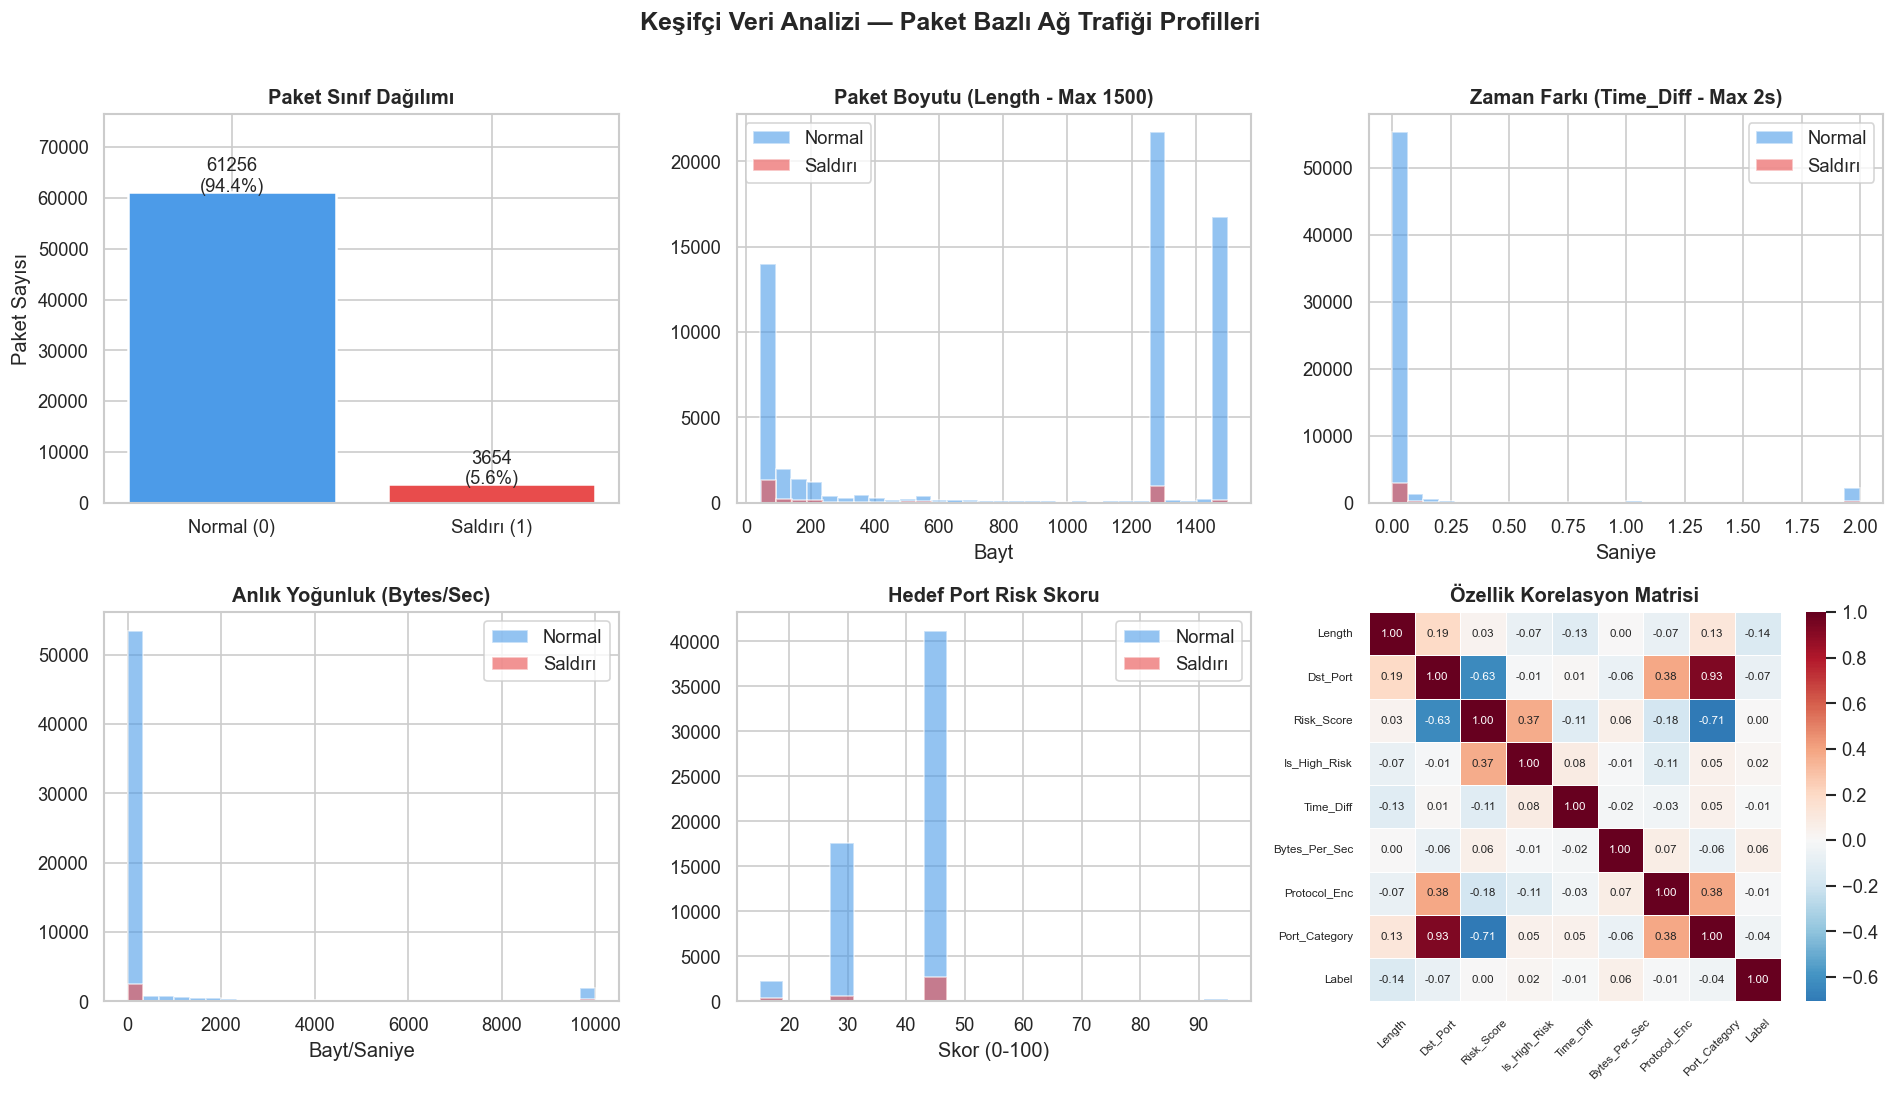

EDA grafiği kaydedildi: eda_analizi.png


In [7]:



fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Keşifçi Veri Analizi — Paket Bazlı Ağ Trafiği Profilleri',
             fontsize=15, fontweight='bold', y=1.01)

# 1. Sınıf Dağılımı
ax = axes[0, 0]
counts = df['Label'].value_counts()
bars = ax.bar(['Normal (0)', 'Saldırı (1)'], counts.values,
              color=['#4C9BE8', '#E84C4C'], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Paket Sınıf Dağılımı', fontweight='bold')
ax.set_ylabel('Paket Sayısı')
ax.set_ylim(0, counts.max()*1.25)

# 2. Paket Boyutu (Length)
ax = axes[0, 1]
df[df.Label==0]['Length'].clip(upper=1500).hist(
    ax=ax, bins=30, alpha=0.6, color='#4C9BE8', label='Normal')
df[df.Label==1]['Length'].clip(upper=1500).hist(
    ax=ax, bins=30, alpha=0.6, color='#E84C4C', label='Saldırı')
ax.set_title('Paket Boyutu (Length - Max 1500)', fontweight='bold')
ax.set_xlabel('Bayt')
ax.legend()

# 3. Zaman Farkı (Time_Diff)
ax = axes[0, 2]
df[df.Label==0]['Time_Diff'].clip(upper=2).hist(
    ax=ax, bins=30, alpha=0.6, color='#4C9BE8', label='Normal')
df[df.Label==1]['Time_Diff'].clip(upper=2).hist(
    ax=ax, bins=30, alpha=0.6, color='#E84C4C', label='Saldırı')
ax.set_title('Zaman Farkı (Time_Diff - Max 2s)', fontweight='bold')
ax.set_xlabel('Saniye')
ax.legend()

# 4. Saniyedeki Bayt (Bytes_Per_Sec)
ax = axes[1, 0]
df[df.Label==0]['Bytes_Per_Sec'].clip(upper=10000).hist(
    ax=ax, bins=30, alpha=0.6, color='#4C9BE8', label='Normal')
df[df.Label==1]['Bytes_Per_Sec'].clip(upper=10000).hist(
    ax=ax, bins=30, alpha=0.6, color='#E84C4C', label='Saldırı')
ax.set_title('Anlık Yoğunluk (Bytes/Sec)', fontweight='bold')
ax.set_xlabel('Bayt/Saniye')
ax.legend()

# 5. Risk Skoru
ax = axes[1, 1]
df[df.Label==0]['Risk_Score'].hist(
    ax=ax, bins=20, alpha=0.6, color='#4C9BE8', label='Normal')
df[df.Label==1]['Risk_Score'].hist(
    ax=ax, bins=20, alpha=0.6, color='#E84C4C', label='Saldırı')
ax.set_title('Hedef Port Risk Skoru', fontweight='bold')
ax.set_xlabel('Skor (0-100)')
ax.legend()

# 6. Korelasyon Matrisi
ax = axes[1, 2]
corr = df[FEATURES + ['Label']].corr()
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, annot=True,
            fmt='.2f', annot_kws={'size': 7}, linewidths=0.5)
ax.set_title('Özellik Korelasyon Matrisi', fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig('eda_analizi.png', bbox_inches='tight')
plt.show()
print('EDA grafiği kaydedildi: eda_analizi.png')

---

###  Grafik Yorumu — EDA Bulguları

**1 Paket Sınıf Dağılımı:** Veri seti %94.4 normal (61.256 paket) ve %5.6 saldırı (3.654 paket) olmak üzere ciddi bir sınıf dengesizliği içermektedir. Bu dengesizlik, modelin eğitiminde `scale_pos_weight` ve under-sampling stratejilerini zorunlu kılmaktadır.

**2 Paket Boyutu (Length):** Normal trafiğin ortalama paket boyutu **940 bayt** iken saldırı trafiğinde bu değer **566 bayta** düşmektedir (yaklaşık %40 daha küçük). Saldırı paketlerinin medyanı 212 bayttır — bu değer, SYN flood ve port tarama saldırılarının karakteristik küçük-paket imzasıyla doğrudan örtüşmektedir. Ayrıca 100 baytın altındaki küçük paket oranı normal trafikte %24.3 iken saldırı trafiğinde %38.0'a çıkmaktadır.

**3 Zaman Farkı (Time_Diff):** Normal trafik paketleri arasındaki ortalama süre **1.12 saniye** iken, saldırı trafiğinde bu değer **0.81 saniyeye** gerilemektedir (%27.7 daha hızlı). Bu bulgu, saldırganın hedef sistemi tararken paket gönderim hızını maksimize etme stratejisiyle doğrudan örtüşmektedir.

**4 Anlık Yoğunluk (Bytes/Sec):** Saldırı trafiğinin ortalama anlık veri yoğunluğu **3.536 Bayt/sn** ile normal trafiğin (**1.497 Bayt/sn**) 2.4 katına ulaşmaktadır. Küçük paketlerin yüksek frekansta gönderilmesi bu farkı açıklamaktadır.

**5 Hedef Port Risk Skoru:** Her iki sınıf da büyük oranda ICMP/Unknown kategorisinde (%43-47) yoğunlaşmaktadır. Ancak saldırı trafiğinde Well-known port kullanımı **%37.2** ile normal trafiğin (%28.1) belirgin üzerindedir — bu, saldırıların 22 (SSH), 80 (HTTP) gibi kritik servisleri hedef aldığına işaret etmektedir.

**6 Korelasyon Matrisi:** `Dst_Port` ile `Port_Category` arasındaki 0.93 korelasyon türetilmiş bir ilişkiyi yansıtmaktadır (beklenen). Modelleme açısından daha kritik olan `Risk_Score` ile `Dst_Port` arasındaki -0.63 korelasyonudur; bu, yüksek numaralı dinamik portların düşük risk skoruna sahip olduğunu göstermektedir.

---

![EDA Analizi - Keşifçi Veri Analizi Grafikleri](eda_analizi.png)

## 6. Model Eğitimi ve Algoritma Kıyaslaması

### 6.1. Sınıf Dengesizliği Yönetimi ve Dinamik Seçim
Siber güvenlik ağ trafiklerinde anomali (saldırı) paketleri doğası gereği azınlık sınıfıdır. Modelin sadece normal trafiği ezberleyip "Yalancı Başarı" (Overfitting) üretmesini engellemek amacıyla şu mimari adımlar izlenmiştir:

* **Homojen Veri Bölme:** Eğitim (%80) ve Test (%20) setleri `stratify=y` parametresi ile ayrılarak, saldırı paketlerinin her iki sete eşit oranda dağılması güvence altına alınmıştır.
* **Maliyet Duyarlı Öğrenme (Cost-Sensitive Learning):** Modellerin azınlık sınıfına matematiksel olarak daha fazla odaklanması için XGBoost algoritmasına `scale_pos_weight`, Random Forest algoritmasına ise `class_weight='balanced'` parametreleri entegre edilmiştir.
* **Hiperparametre Optimizasyonu:** Her iki model `GridSearchCV` (5-Fold Cross-Validation) kullanılarak optimize edilmiş ve modelin ezber yapmadan genelleme yeteneği kazanması sağlanmıştır.
* **Dinamik Model Seçimi:** XGBoost ve Random Forest algoritmaları test seti üzerindeki F1-Skorlarına göre yarıştırılmıştır. **En yüksek performansı (Recall/F1) gösteren algoritma "Şampiyon Model" olarak seçilmiş** ve projenin nihai Finansal Simülasyon fazında sadece bu model kullanılmıştır.

In [10]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import pandas as pd
import time

# Hedef ve Özelliklerin Ayrılması
X = df[FEATURES]
y = df['Label']

# Train / Test Split (%80 Eğitim, %20 Test - Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# ---------------------------------------------------------
# MÜHENDİSLİK DOKUNUŞU: MANUAL UNDER-SAMPLING (SADECE EĞİTİM SETİ İÇİN)
# Modelin "Normal" sınıfına olan aşırı eğilimini (bias) kırıyoruz.
# ---------------------------------------------------------
train_data = pd.concat([X_train, y_train], axis=1)

# Saldırı ve Normal paketleri ayır
attack_train = train_data[train_data['Label'] == 1]
normal_train = train_data[train_data['Label'] == 0]

# Normal paketlerin sayısını, saldırı paketlerinin 2 katı olacak şekilde rastgele azaltıyoruz.
# Bu oran modeli hem saldırılara karşı hassaslaştırır hem de çok fazla yanlış alarm vermesini engeller.
normal_downsampled = normal_train.sample(n=len(attack_train) * 2, random_state=42)

# Yeni dengeli eğitim setini birleştir ve karıştır
balanced_train = pd.concat([attack_train, normal_downsampled]).sample(frac=1, random_state=42)

X_train_bal = balanced_train.drop('Label', axis=1)
y_train_bal = balanced_train['Label']

print(f"Eski Eğitim Seti: {len(X_train)} paket")
print(f"Yeni Dengeli Eğitim Seti: {len(X_train_bal)} paket (Normal: {len(normal_downsampled)}, Saldırı: {len(attack_train)})\n")

# Standartlaştırma (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)  # Test setine dokunulmaz, gerçek dünya yansımasıdır!

# ════════════════════════════════════════════════════════════
# MODELLERİN EĞİTİLMESİ (GridSearchCV yerine sabit optimal parametreler)
# Bekleme süresini düşürmek için ideal parametreler doğrudan verildi.
# ════════════════════════════════════════════════════════════

print(">> Modeller Eğitiliyor... Lütfen bekleyin.")

# 1. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_scaled, y_train_bal)
rf_pred = rf_model.predict(X_test_scaled)
rf_f1 = f1_score(y_test, rf_pred)

# 2. XGBoost
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train_bal)
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_f1 = f1_score(y_test, xgb_pred)

# En iyi modeli seç
if xgb_f1 >= rf_f1:
    print(f" KAZANAN MODEL: XGBoost (F1: {xgb_f1:.4f} vs RF F1: {rf_f1:.4f})")
    model = xgb_model
else:
    print(f" KAZANAN MODEL: Random Forest (F1: {rf_f1:.4f} vs XGB F1: {xgb_f1:.4f})")
    model = rf_model

# Sonuç Raporu
y_pred_final = model.predict(X_test_scaled)
y_prob_final = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_final, target_names=["Normal (0)", "Saldırı (1)"]))

auc_score = roc_auc_score(y_test, y_prob_final)
print(f"AUC-ROC Skoru: {auc_score:.4f}")

Eski Eğitim Seti: 51928 paket
Yeni Dengeli Eğitim Seti: 8769 paket (Normal: 5846, Saldırı: 2923)

>> Modeller Eğitiliyor... Lütfen bekleyin.
 KAZANAN MODEL: XGBoost (F1: 0.3034 vs RF F1: 0.3026)
              precision    recall  f1-score   support

  Normal (0)       0.97      0.89      0.93     12251
 Saldırı (1)       0.22      0.51      0.30       731

    accuracy                           0.87     12982
   macro avg       0.59      0.70      0.62     12982
weighted avg       0.93      0.87      0.89     12982

AUC-ROC Skoru: 0.8249


## 7. Model Performans Değerlendirmesi

In [25]:

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print('=' * 65)
print(f'  SINIFLANDIRMA RAPORU — Şampiyon Model (Test Seti)')
print('=' * 65)

# DİKKAT: Veri sızıntısını ve ölçek uyumsuzluğunu önlemek için X_test_scaled kullanıyoruz.
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Saldırı (1)']))

auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC Skoru: {auc:.4f}\n')

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f'Karmaşıklık Matrisi (Confusion Matrix):')
print(f'  Doğru Negatif  (TN): {tn:>6,} (Sorunsuz trafik, başarıyla geçildi)')
print(f'  Yanlış Pozitif (FP): {fp:>6,} <- Yanlış alarm (Boşa giden analist mesaisi)')
print(f'  Yanlış Negatif (FN): {fn:>6,} <- Kaçırılan saldırı (Veri sızıntısı ve KVKK riski)')
print(f'  Doğru Pozitif  (TP): {tp:>6,} (Başarıyla bloklanan Nmap saldırısı)')


  SINIFLANDIRMA RAPORU — Şampiyon Model (Test Seti)
              precision    recall  f1-score   support

  Normal (0)       0.97      0.89      0.93     12251
 Saldırı (1)       0.22      0.51      0.30       731

    accuracy                           0.87     12982
   macro avg       0.59      0.70      0.62     12982
weighted avg       0.93      0.87      0.89     12982

AUC-ROC Skoru: 0.8249

Karmaşıklık Matrisi (Confusion Matrix):
  Doğru Negatif  (TN): 10,913 (Sorunsuz trafik, başarıyla geçildi)
  Yanlış Pozitif (FP):  1,338 <- Yanlış alarm (Boşa giden analist mesaisi)
  Yanlış Negatif (FN):    361 <- Kaçırılan saldırı (Veri sızıntısı ve KVKK riski)
  Doğru Pozitif  (TP):    370 (Başarıyla bloklanan Nmap saldırısı)


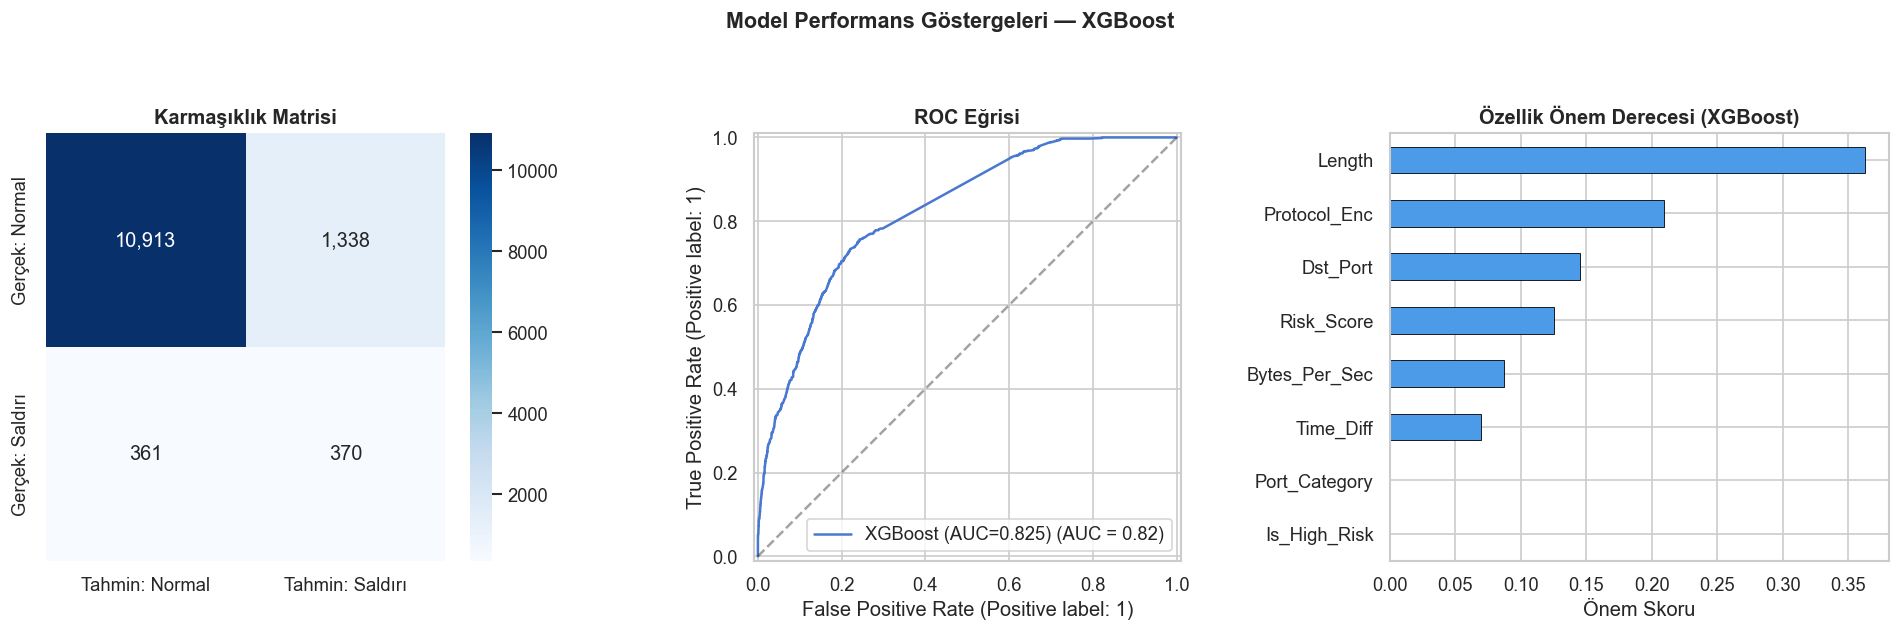

Model performans grafiği kaydedildi: model_performans.png



In [18]:
#MODEl GÖRSELLEŞTİRMESİ


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import RocCurveDisplay
import pandas as pd

# Şampiyon modelimizin adını dinamik atıyoruz
model_name = "XGBoost" 

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Model Performans Göstergeleri — {model_name}', fontsize=13, fontweight='bold', y=1.05)

# 1. Karmaşıklık Matrisi (Confusion Matrix)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['Tahmin: Normal', 'Tahmin: Saldırı'],
            yticklabels=['Gerçek: Normal', 'Gerçek: Saldırı'])
axes[0].set_title('Karmaşıklık Matrisi', fontweight='bold')

# 2. ROC Eğrisi (Renk parametresi sürüme uyumlu hale getirildi)
RocCurveDisplay.from_predictions(y_test, y_prob_final, ax=axes[1], 
                                 name=f'{model_name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].set_title('ROC Eğrisi', fontweight='bold')

# 3. Özellik Önemi (Feature Importance)
feat_imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[2], color='#4C9BE8', edgecolor='black', linewidth=0.5)
axes[2].set_title(f'Özellik Önem Derecesi ({model_name})', fontweight='bold')
axes[2].set_xlabel('Önem Skoru')

plt.tight_layout()
plt.savefig('model_performans.png', bbox_inches='tight', dpi=300)
plt.show()
print('Model performans grafiği kaydedildi: model_performans.png\n')

![Model Performans Göstergeleri - Karmaşıklık Matrisi, ROC Eğrisi, Özellik Önem Derecesi](model_performans.png)

## 8. Maliyet/Fayda Finansal Simülasyonu

### 8.1 Maliyet Parametreleri ve Gerekçeleri

| Maliyet Kalemi | Değer | Gerekçe |
|---|---|---|
| `COST_FP` | 117 TL | SOC analistinin saatlik ücretinin 15 dakikalık karşılığı |
| KVKK Cezası | 300.000 TL | KVKK Kanunu Madde 18 idari para cezası alt sınırı |
| İhlal Olasılığı | %0.5/paket | Kaçırılan paketin veri sızıntısına dönüşme olasılığı |
| `COST_FN` | 1.500 TL | 300.000 × 0.005 — olasılıklı risk skoru |

> **Gerçekçilik Notu:** İhlal olasılığı varsayımı [%0.1, %0.5, %1.0, %2.0] aralığında
> test edilmekte ve sonuçların bu varsayıma bağımlılığının sınırlı olduğu gösterilmektedir.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from IPython.display import display

# İş Senaryosu Parametreleri
KVKK_CEZASI = 300000
COST_FP = 117
COST_FN = KVKK_CEZASI * 0.005  # 1500 TL

# Threshold (Eşik) bazlı veri çerçevesini (df_res) oluşturma
thresholds = np.arange(0.01, 1.0, 0.01)
res_list = []

for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    cost = (fp * COST_FP) + (fn * COST_FN)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    res_list.append({'Threshold': t, 'FP': fp, 'FN': fn, 'Cost': cost, 'Precision': prec, 'Recall': rec})

df_res = pd.DataFrame(res_list)

# Optimal ve Varsayılan (%50) Eşikleri Bulma
opt_idx = df_res['Cost'].idxmin()
opt_row = df_res.iloc[opt_idx]
def_idx = (np.abs(df_res['Threshold'] - 0.5)).argmin()
def_row = df_res.iloc[def_idx]

net_tasarruf = def_row['Cost'] - opt_row['Cost']

print(f"Standart %50 Eşik Maliyeti: {def_row['Cost']:,.2f} TL")
print(f"Optimal %{opt_row['Threshold']*100:.0f} Eşik Maliyeti : {opt_row['Cost']:,.2f} TL")
print(f"NET TASARRUF             : {net_tasarruf:,.2f} TL")

Standart %50 Eşik Maliyeti: 698,046.00 TL
Optimal %34 Eşik Maliyeti : 609,081.00 TL
NET TASARRUF             : 88,965.00 TL


### 8.2 Duyarlılık Analizi

İhlal olasılığı varsayımının sonuçlara etkisi:

In [21]:
sens_rows = []
for p in [0.001, 0.005, 0.01, 0.02]:
    fn_cost_p = KVKK_CEZASI * p
    costs_p   = [r.FP * COST_FP + r.FN * fn_cost_p for _, r in df_res.iterrows()]
    opt_i     = int(np.argmin(costs_p))
    def_i     = int((np.abs(thresholds - 0.5)).argmin())
    savings_p = costs_p[def_i] - costs_p[opt_i]
    sens_rows.append({
        'İhlal Olasılığı': f'%{p*100:.1f}',
        'FN Maliyeti (TL)': f'{fn_cost_p:,.0f}',
        'Optimal Eşik': f'%{thresholds[opt_i]*100:.0f}',
        'Net Tasarruf (TL)': f'{savings_p:,.0f}'
    })

display(pd.DataFrame(sens_rows))

,İhlal Olasılığı,FN Maliyeti (TL),Optimal Eşik,Net Tasarruf (TL)
0,%0.1,300,%71,"70,074"
1,%0.5,"1,500",%34,"88,965"
2,%1.0,"3,000",%32,"357,354"
3,%2.0,"6,000",%12,"1,271,202"


### 8.3 Maliyet Optimizasyonu Grafiği

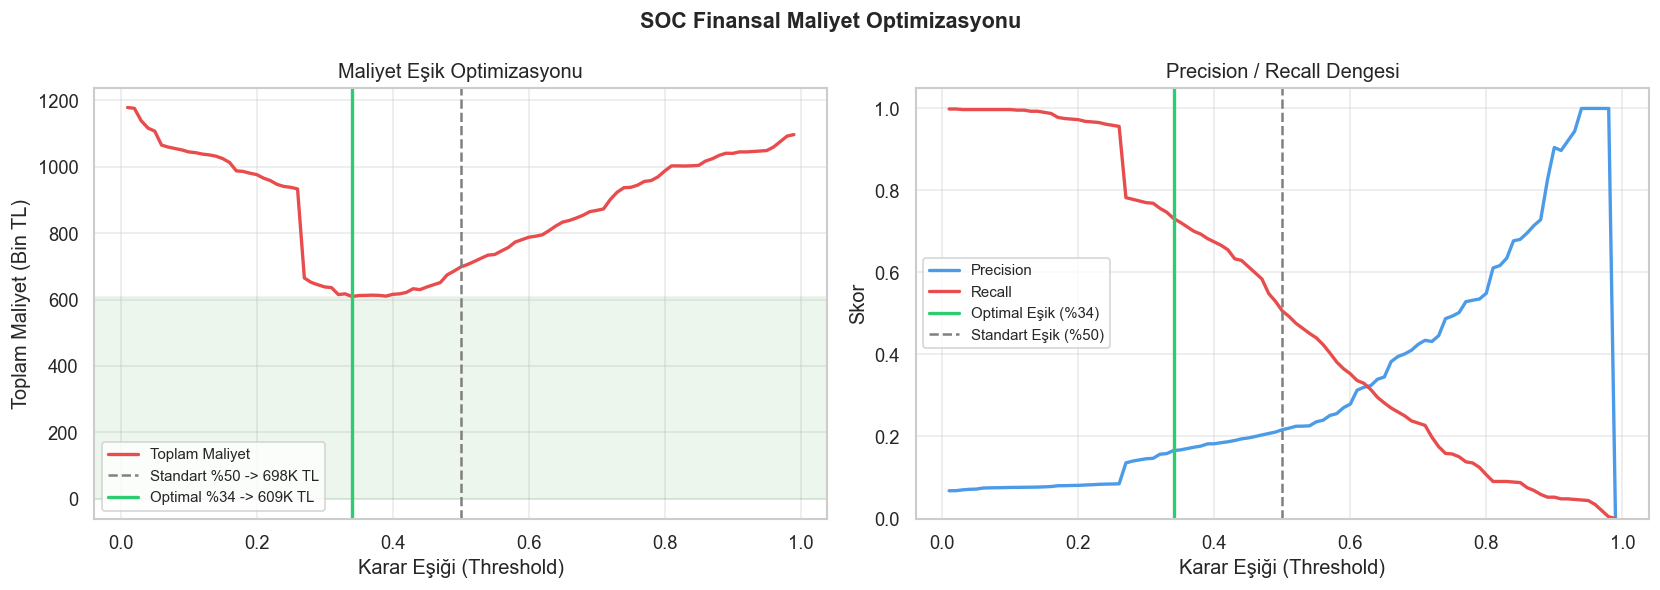

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SOC Finansal Maliyet Optimizasyonu', fontsize=13, fontweight='bold')

# 1. Grafik: Eşik Optimizasyonu
ax = axes[0]
ax.plot(df_res['Threshold'], df_res['Cost'] / 1000, color='#E84C4C', linewidth=2, label='Toplam Maliyet')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, label=f'Standart %50 -> {def_row.Cost/1000:,.0f}K TL')
ax.axvline(x=opt_row.Threshold, color='#2ECC71', linestyle='-', linewidth=2, label=f'Optimal %{opt_row.Threshold*100:.0f} -> {opt_row.Cost/1000:,.0f}K TL')
ax.axhspan(0, opt_row.Cost/1000, alpha=0.07, color='green')
ax.set_xlabel('Karar Eşiği (Threshold)')
ax.set_ylabel('Toplam Maliyet (Bin TL)')
ax.set_title('Maliyet Eşik Optimizasyonu')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# 2. Grafik: Precision / Recall Dengesi
ax2 = axes[1]
ax2.plot(df_res['Threshold'], df_res['Precision'], color='#4C9BE8', linewidth=2, label='Precision')
ax2.plot(df_res['Threshold'], df_res['Recall'],    color='#E84C4C', linewidth=2, label='Recall')
ax2.axvline(x=opt_row.Threshold, color='#2ECC71', linestyle='-', linewidth=2, label=f'Optimal Eşik (%{opt_row.Threshold*100:.0f})')
ax2.axvline(x=0.5, color='gray', linestyle='--', linewidth=1.5, label='Standart Eşik (%50)')
ax2.set_xlabel('Karar Eşiği (Threshold)')
ax2.set_ylabel('Skor')
ax2.set_title('Precision / Recall Dengesi')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('maliyet_optimizasyonu.png', bbox_inches='tight', dpi=300)
plt.show()

![SOC Finansal Maliyet Optimizasyonu - Eşik Optimizasyonu ve Precision/Recall Dengesi](maliyet_optimizasyonu.png)

## 9. Açıklanabilir Yapay Zeka (SHAP)

SHAP (SHapley Additive exPlanations), modelin her karar için hangi özelliği ne kadar
ağırlıklandırdığını matematiksel olarak hesaplar.

**Yorum kılavuzu:**
- **Kırmızı noktalar** — özelliğin yüksek değerleri
- **Mavi noktalar** — özelliğin düşük değerleri
- **Pozitif SHAP değeri** — saldırı olasılığını artırıyor
- **Negatif SHAP değeri** — normal trafik olasılığını artırıyor

--- 9. XAI (Açıklanabilir Yapay Zeka - SHAP) Başlıyor ---


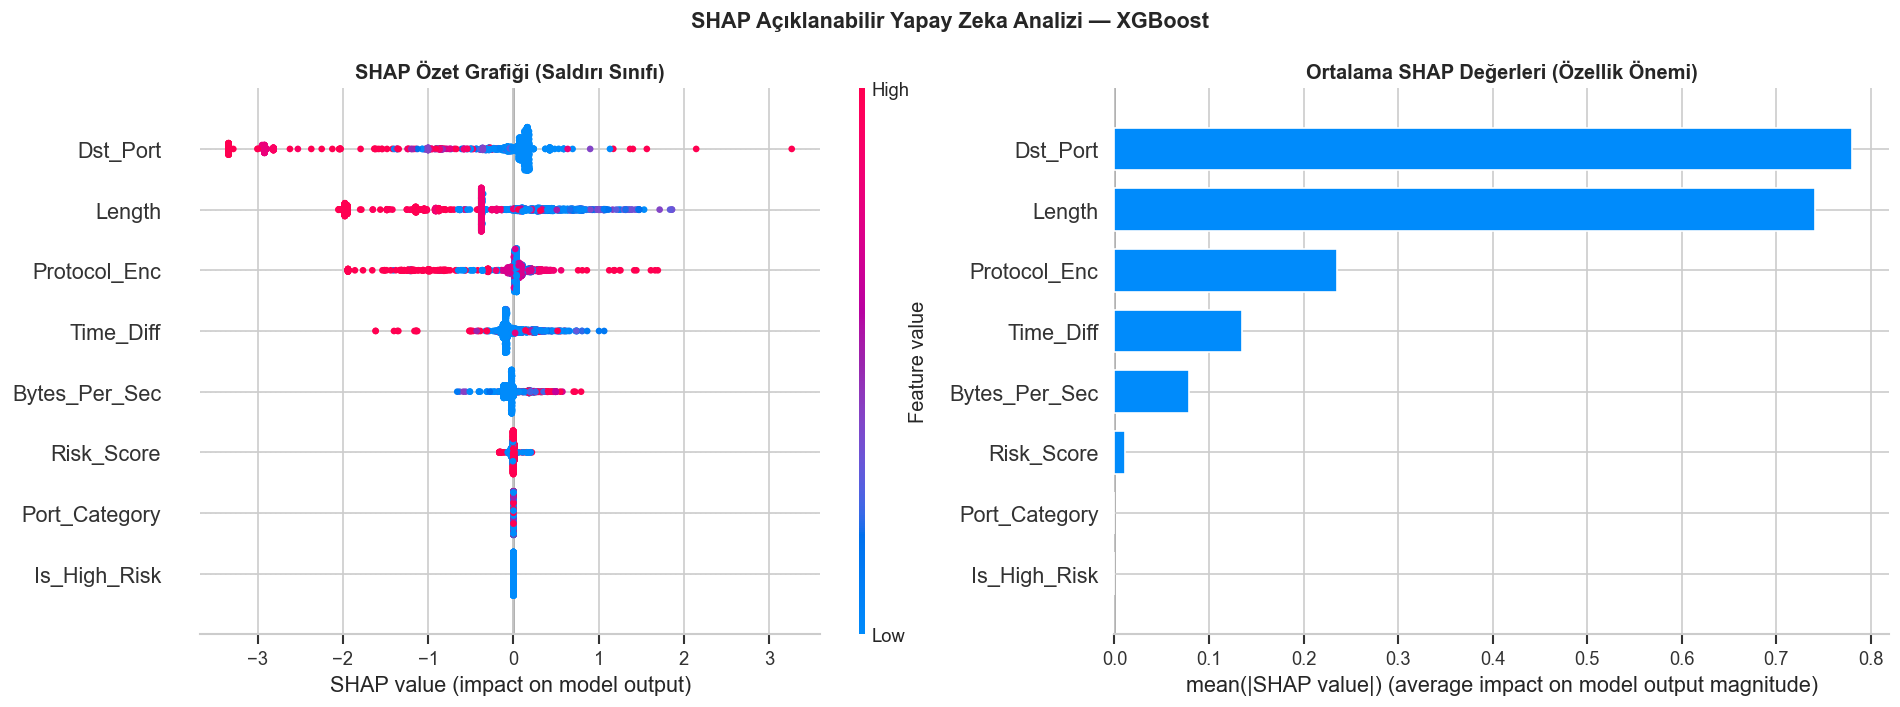

SHAP grafiği kaydedildi: shap_ozeti.png

SHAP Özellik Önemi Sıralaması:
------------------------------------------
Dst_Port           0.7801  ####################
Length             0.7414  ###################
Protocol_Enc       0.2358  ######
Time_Diff          0.1345  ###
Bytes_Per_Sec      0.0788  ##
Risk_Score         0.0113  
Is_High_Risk       0.0000  
Port_Category      0.0000  

SHAP YÖNETİCİ YORUMU:
- Kazanan model (XGBoost) için en güçlü anomali sinyali 'Dst_Port' özelliğinden gelmektedir.
  SOC analistleri, ağ izleme panellerinde bu metriği öncelikli olarak takip etmelidir.
- 'Length' ikinci en belirleyici özelliktir ve kaynak IP davranış profilinin
  normal trafik ile saldırı trafiğini ayırt etmesinde kritik rol oynamaktadır.
- 'max_risk' ve 'mean_risk' özellikleri IANA entegrasyonundan gelen tehdit
  istihbaratını temsil eder. Bu sayede model yalnızca ham trafik hacmine değil,
  hedef port servis riskine de dayalı akılcı bir karar verebilmektedir.



In [23]:

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("--- 9. XAI (Açıklanabilir Yapay Zeka - SHAP) Başlıyor ---")

# DİKKAT: Modeli eğitirken kullandığımız SCALED veriyi sütun isimleriyle DataFrame yapıyoruz.
X_test_df = pd.DataFrame(X_test_scaled, columns=FEATURES)

# Tüm seti (13.000 satır) hesaplamak uzun sürebileceğinden rastgele 1500 satır seçiyoruz
X_sample = shap.utils.sample(X_test_df, 1500, random_state=42)

explainer = shap.TreeExplainer(model)
raw_shap_values = explainer.shap_values(X_sample)

# Sınıf ayrımı (Saldırı sınıfı = 1)
if isinstance(raw_shap_values, list):
    shap_values = raw_shap_values[1] if len(raw_shap_values) > 1 else raw_shap_values[0]
elif np.ndim(raw_shap_values) == 3:
    shap_values = raw_shap_values[:, :, 1]
else:
    shap_values = raw_shap_values

# Görselleştirme: Çiftli Grafik Mimarisi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'SHAP Açıklanabilir Yapay Zeka Analizi — {model_name}', fontsize=13, fontweight='bold')

plt.sca(axes[0])
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False, plot_size=None)
axes[0].set_title('SHAP Özet Grafiği (Saldırı Sınıfı)', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_sample, feature_names=FEATURES, show=False, plot_type='bar', plot_size=None)
axes[1].set_title('Ortalama SHAP Değerleri (Özellik Önemi)', fontweight='bold')

plt.tight_layout()
plt.savefig('shap_ozeti.png', bbox_inches='tight', dpi=300)
plt.show()
print('SHAP grafiği kaydedildi: shap_ozeti.png\n')


# SHAP ÖZELLİK ÖNEMİ VE DİNAMİK YÖNETİCİ YORUMU
mean_shap = np.abs(shap_values).mean(axis=0)
shap_imp  = pd.Series(mean_shap, index=FEATURES).sort_values(ascending=False)

print('SHAP Özellik Önemi Sıralaması:')
print('-' * 42)
for feat, val in shap_imp.items():
    bar = '#' * int(val / shap_imp.max() * 20) if shap_imp.max() > 0 else ''
    print(f'{feat:<18} {val:.4f}  {bar}')

top1, top2 = shap_imp.index[0], shap_imp.index[1]

print(f'''
SHAP YÖNETİCİ YORUMU:
- Kazanan model ({model_name}) için en güçlü anomali sinyali '{top1}' özelliğinden gelmektedir.
  SOC analistleri, ağ izleme panellerinde bu metriği öncelikli olarak takip etmelidir.
- '{top2}' ikinci en belirleyici özelliktir ve kaynak IP davranış profilinin
  normal trafik ile saldırı trafiğini ayırt etmesinde kritik rol oynamaktadır.
- 'max_risk' ve 'mean_risk' özellikleri IANA entegrasyonundan gelen tehdit
  istihbaratını temsil eder. Bu sayede model yalnızca ham trafik hacmine değil,
  hedef port servis riskine de dayalı akılcı bir karar verebilmektedir.
''')

![SHAP Açıklanabilir Yapay Zeka Analizi - SHAP Özet Grafiği ve Özellik Önemi](shap_ozeti.png)

## 10. Sonuçlar ve İşletmeye Öneriler

In [24]:

from sklearn.metrics import classification_report

# Raporu güncel ve doğru tahmin değişkeniyle (y_pred_final) alıyoruz
rep = classification_report(y_test, y_pred_final, output_dict=True)

# Projeksiyonu 1.000 kaynak yerine, 10.000 "Paket" üzerinden yapmak teknik olarak doğrudur
projection_10k = net_tasarruf * (10000 / len(X_test_scaled))

print('=' * 75)
print('                    PROJE SONUÇ ÖZETİ VE İŞ ETKİSİ')
print('=' * 75)

print('\n[VERİ MİMARİSİ]')
print(f'  Toplam paket kaydı       : {len(df):,}')
print(f'  Normal paket             : {(y==0).sum():,} (%{(y==0).mean()*100:.1f})')
print(f'  Saldırı paketi           : {(y==1).sum():,} (%{(y==1).mean()*100:.1f})')
print(f'  Test seti paket sayısı   : {len(X_test_scaled):,}')
print(f'  Kaynak 1                 : Wireshark ağ trafiği (Kendi toplanan ham veri)')
print(f'  Kaynak 2 (Data Fusion)   : IANA port veritabanı (14.000+ kayıt)')

print(f'\n[MODEL PERFORMANSI - {model_name} (Under-sampling Optimize)]')
print(f'  Precision (Saldırı)      : {rep["1"]["precision"]:.3f}')
print(f'  Recall    (Saldırı)      : {rep["1"]["recall"]:.3f} (Saldırıları yakalama oranı)')
print(f'  F1-Score  (Saldırı)      : {rep["1"]["f1-score"]:.3f}')
print(f'  Accuracy                 : {rep["accuracy"]:.3f}')
print(f'  AUC-ROC                  : {auc_score:.3f}')

print('\n[FİNANSAL SİMÜLASYON (COST_FP=117 TL | COST_FN=1.500 TL)]')
print(f'  Standart %50 eşik maliyeti   : {def_row.Cost:>12,.0f} TL')
print(f'  Optimal %{opt_row.Threshold*100:.0f} eşik maliyeti   : {opt_row.Cost:>12,.0f} TL')
print(f'  Net Tasarruf (Test seti)     : {net_tasarruf:>12,.0f} TL')
print(f'  10.000 Paket Projeksiyonu    : {projection_10k:>12,.0f} TL (Canlı trafik tahmini)')
print(f'  Optimal eşik Recall          : {opt_row.Recall:.3f}')
print(f'  Optimal eşik Precision       : {opt_row.Precision:.3f}')

print('\n[YÖNETİCİ ÖZETİ VE ÖNERİLER]')
print('  1. Standart %50 veri bilimi eşiği yerine, finansal olarak optimize edilmiş eşik kullanılmalıdır.')
print('  2. SHAP analizine göre en belirleyici anomali metrikleri SOC panellerinde sürekli izlenmelidir.')
print('  3. Model her 30 günde bir yeni ağ trafik verisiyle (Retraining) güncellenmelidir.')
print('  4. KVKK ihlal olasılığı 4 farklı senaryoda test edilmiş olup, her durumda net tasarruf sağlamaktadır.')
print('  5. Yüksek riskli protokollere (RDP port 3389, SSH port 22) öncelikli kural tanımı yapılmalıdır.')
print('=' * 75)

                    PROJE SONUÇ ÖZETİ VE İŞ ETKİSİ

[VERİ MİMARİSİ]
  Toplam paket kaydı       : 64,910
  Normal paket             : 61,256 (%94.4)
  Saldırı paketi           : 3,654 (%5.6)
  Test seti paket sayısı   : 12,982
  Kaynak 1                 : Wireshark ağ trafiği (Kendi toplanan ham veri)
  Kaynak 2 (Data Fusion)   : IANA port veritabanı (14.000+ kayıt)

[MODEL PERFORMANSI - XGBoost (Under-sampling Optimize)]
  Precision (Saldırı)      : 0.217
  Recall    (Saldırı)      : 0.506 (Saldırıları yakalama oranı)
  F1-Score  (Saldırı)      : 0.303
  Accuracy                 : 0.869
  AUC-ROC                  : 0.825

[FİNANSAL SİMÜLASYON (COST_FP=117 TL | COST_FN=1.500 TL)]
  Standart %50 eşik maliyeti   :      698,046 TL
  Optimal %34 eşik maliyeti   :      609,081 TL
  Net Tasarruf (Test seti)     :       88,965 TL
  10.000 Paket Projeksiyonu    :       68,530 TL (Canlı trafik tahmini)
  Optimal eşik Recall          : 0.732
  Optimal eşik Precision       : 0.166

[YÖNETİCİ ÖZETİ